# [의료보험료 예측 모델 고도화 (PyTorch MLP Regression - Ver 3.0)]

## 프로젝트 개요 및 Ver 3.0 개선 방향
본 단계에서는 이전 버전들에서 확인된 통계적 한계를 극복하고, 모델의 일반화 성능과 해석 가능성을 확보하는 데 집중합니다. 단순히 점수를 높이는 것을 넘어, 신뢰할 수 있는 파이프라인을 구축하는 것을 목적으로 합니다.

<br>

---

<br>

## Ver 3.0 핵심 개선 사항 (Professional Techniques)


**1. K-Fold 교차 검증 (Cross-Validation)**
* **문제점:** 단일 Split(`random_state=2024`) 결과는 데이터 분할 운에 따라 성능이 과대평가될 위험이 있음.
* **해결책:** 데이터를 5개의 폴드(Fold)로 나누어 모든 데이터에 대해 학습 및 검증을 반복 수행. 평균 성능과 표준편차를 보고하여 모델의 통계적 안정성을 검증함.

<br>

**2. 과적합 방지 (Regularization: Dropout & Weight Decay)**
* **문제점:** 딥러닝 모델의 복잡도가 데이터 수에 비해 높아질 경우, 학습 데이터에만 과하게 최적화될 수 있음.
* **해결책:**
    * **Dropout:** 학습 시 무작위로 뉴런을 생략하여 특정 피처에 대한 의존성을 강제로 분산.
    * **Weight Decay (L2 Regularization):** 가중치 파라미터가 너무 커지지 않도록 억제하여 모델의 복잡도를 제어.

<br>

**3. 모델 해석성 확보 (Model Interpretability with SHAP)**
* **문제점:** 신경망(MLP)은 '블랙박스' 모델로, 어떤 변수가 보험료 책정에 구체적으로 얼마나 기여했는지 알기 어려움.
* **해결책:** **SHAP(SHapley Additive exPlanations)** 라이브러리를 도입하여 '흡연', 'BMI', '교호작용 변수' 등이 개별 예측치에 미치는 영향력을 정량적으로 분석하고 시각화함.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

data_path = '/content/drive/MyDrive/Colab Notebooks/PyTorch 실습 /insurance.csv'

df = pd.read_csv(data_path)

#1. 데이터 전처리 및 K-Fold 준비

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import defaultdict
import shap  # pip install shap 필요

# ---------------------------------------------------------
# [A] 인코더 클래스 정의
# ---------------------------------------------------------
class MultiLabelEncoder:
    def __init__(self):
        self.label_encoders = defaultdict(LabelEncoder)
    def fit(self, X, columns):
        for column in columns: self.label_encoders[column].fit(X[column])
        return self
    def transform(self, X, columns):
        X_transformed = X.copy()
        for column in columns: X_transformed[column] = self.label_encoders[column].transform(X[column])
        return X_transformed

class DataFrameOneHotEncoder:
    def __init__(self):
        self.encoder = OneHotEncoder(sparse_output=False)
    def fit(self, X, columns):
        self.columns = columns
        self.encoder.fit(X[columns])
        self.feature_names = self.encoder.get_feature_names_out(columns)
        return self
    def transform(self, X):
        X_transformed = X.drop(columns=self.columns).reset_index(drop=True)
        encoded_columns = pd.DataFrame(self.encoder.transform(X[self.columns]), columns=self.feature_names)
        return pd.concat([X_transformed, encoded_columns], axis=1)

# ---------------------------------------------------------
# [B] 데이터 로드 및 🚀 고급 파생 변수(Interaction) 추가
# ---------------------------------------------------------
# df = pd.read_csv(data_path) # 이미 로드되어 있다면 주석 유지

smoker_binary = (df['smoker'] == 'yes').astype(int)

# 파생 변수 3종 추가
df['high_risk'] = (smoker_binary & (df['bmi'] >= 30.0)).astype(int)
df['age_x_smoker'] = df['age'] * smoker_binary
df['bmi_x_smoker'] = df['bmi'] * smoker_binary

print("✅ 파생 변수 3종 추가 완료!")

# ---------------------------------------------------------
# [C] 🚀 Train_Val / Test Split (에러 수정 부분)
# ---------------------------------------------------------
x = df.copy().drop(columns=['charges'])
y = df.copy()['charges']

# 최종 평가를 위한 Test(20%)를 떼어두고, 나머지(80%)를 K-Fold용(x_train_val)으로 묶습니다.
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=2024)

# ---------------------------------------------------------
# [D] 인코딩 적용 (x_train_val 기준)
# ---------------------------------------------------------
label_cols = ['sex', 'smoker']
multilabelencoder = MultiLabelEncoder().fit(x_train_val, label_cols)
x_train_val = multilabelencoder.transform(x_train_val, label_cols)
x_test = multilabelencoder.transform(x_test, label_cols)

oe_cols = ['region']
onehotencoder = DataFrameOneHotEncoder().fit(x_train_val, oe_cols)
x_train_val = onehotencoder.transform(x_train_val.copy())
x_test = onehotencoder.transform(x_test.copy())

# ---------------------------------------------------------
# [E] 스케일링 적용 (x_train_val 기준)
# ---------------------------------------------------------
scaler = StandardScaler()
numeric_cols = list(set(x_train_val.select_dtypes(exclude="object").columns))

scaler.fit(x_train_val[numeric_cols])
x_train_val[numeric_cols] = scaler.transform(x_train_val[numeric_cols].copy())
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols].copy())

# ---------------------------------------------------------
# [F] K-Fold 루프에서 사용하기 위해 Index 초기화 및 변수 할당
# ---------------------------------------------------------
X = x_train_val.copy().reset_index(drop=True)
Y = y_train_val.copy().reset_index(drop=True)

# 텐서 변환 (최종 평가용 Test 셋만 미리 변환해 둡니다)
x_test_tensor = torch.Tensor(x_test.values)
y_test_tensor = torch.Tensor(y_test.values).unsqueeze(1)

input_dim = X.shape[1]
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ 데이터 분할 및 전처리 완료! 현재 Input Dimension: {input_dim}")

✅ 파생 변수 3종 추가 완료!
✅ 데이터 분할 및 전처리 완료! 현재 Input Dimension: 12


#2. 정규화가 적용된 모델 정의

In [5]:
class ProInsuranceModel(nn.Module):
    def __init__(self, input_dim, n1, n2, n3, dropout_rate=0.2):
        super(ProInsuranceModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, n1),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # 🚀 Dropout 추가

            nn.Linear(n1, n2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(n2, n3),
            nn.ReLU(),
            nn.Linear(n3, 1)
        )

    def forward(self, x):
        return self.net(x)

#3. K-Fold 교차 검증 및 Weight Decay 적용

In [7]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# K-Fold 설정 (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

fold_results_r2 = []
fold_results_mae = []

epochs = 300 # 시간 관계상 300으로 설정
batch_size = 64

print("🚀 K-Fold 교차 검증 (Cross-Validation) 시작...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # 1. Fold별 데이터 분할 (앞선 셀에서 정의한 X, Y 사용)
    x_t, x_v = X.iloc[train_idx], X.iloc[val_idx]
    y_t, y_v = Y.iloc[train_idx], Y.iloc[val_idx]

    # 2. 텐서 변환 및 DataLoader 생성
    x_train_fold = torch.Tensor(x_t.values)
    y_train_fold = torch.Tensor(y_t.values).unsqueeze(1)
    x_val_fold = torch.Tensor(x_v.values)
    y_val_fold = torch.Tensor(y_v.values).unsqueeze(1)

    train_ds = TensorDataset(x_train_fold, y_train_fold)
    val_ds = TensorDataset(x_val_fold, y_val_fold)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # 3. 모델 초기화 (Dropout이 적용된 ProInsuranceModel, 노드 수 44->22->19 적용)
    model = ProInsuranceModel(input_dim, 44, 22, 19, dropout_rate=0.2).to(device)

    # 4. 🚀 Optimizer 설정 (Weight Decay: L2 정규화 적용) 및 Loss 선언
    optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)
    loss_fn = nn.HuberLoss().to(device)

    # 5. 폴드별 모델 학습 루프
    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x_batch), y_batch)
            loss.backward()
            optimizer.step()

    # 6. 폴드별 검증 (Validation) 평가
    model.eval()
    val_preds_list = []
    val_trues_list = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            preds = model(x_batch.to(device)).cpu().numpy()
            val_preds_list.extend(preds)
            val_trues_list.extend(y_batch.numpy())

    # 7. 평가 지표 계산 및 기록
    current_fold_r2 = r2_score(val_trues_list, val_preds_list)
    current_fold_mae = mean_absolute_error(val_trues_list, val_preds_list)

    fold_results_r2.append(current_fold_r2)
    fold_results_mae.append(current_fold_mae)

    print(f"Fold {fold+1} 완료 => R2 Score: {current_fold_r2:.4f} | MAE: {current_fold_mae:,.2f}")

# 8. 최종 K-Fold 결과 출력
print("\n" + "="*50)
print(" 🏆 K-Fold 교차 검증 최종 결과 (Validation 기준)")
print("="*50)
print(f" ▪ 평균 R2 Score : {np.mean(fold_results_r2):.4f} (± {np.std(fold_results_r2):.4f})")
print(f" ▪ 평균 MAE      : {np.mean(fold_results_mae):,.2f} (± {np.std(fold_results_mae):,.2f})")
print("="*50)

🚀 K-Fold 교차 검증 (Cross-Validation) 시작...

Fold 1 완료 => R2 Score: 0.8749 | MAE: 1,489.31
Fold 2 완료 => R2 Score: 0.8933 | MAE: 1,336.36
Fold 3 완료 => R2 Score: 0.8262 | MAE: 1,751.13
Fold 4 완료 => R2 Score: 0.8177 | MAE: 1,629.85
Fold 5 완료 => R2 Score: 0.8747 | MAE: 1,466.97

 🏆 K-Fold 교차 검증 최종 결과 (Validation 기준)
 ▪ 평균 R2 Score : 0.8574 (± 0.0298)
 ▪ 평균 MAE      : 1,534.72 (± 142.75)


#4. 모델 해석 (SHAP 분석)

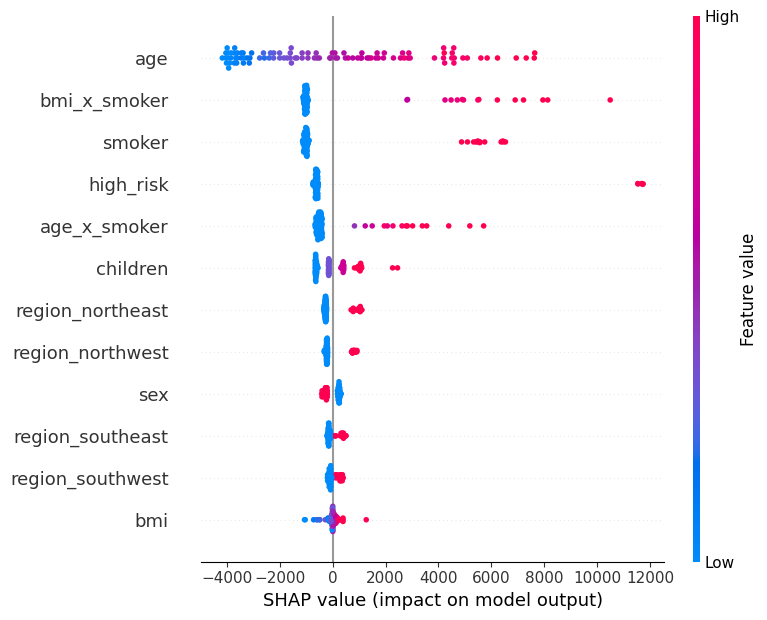

In [9]:
import shap
import matplotlib.pyplot as plt

# 1. SHAP 값 계산 (속도를 위해 앞의 100개 샘플만 사용)
background_data = x_test_tensor[:100].to(device)
explainer = shap.DeepExplainer(model, background_data)
shap_values = explainer.shap_values(background_data)

# 2. 차원(Dimension) 평탄화 보정 작업
# 딥러닝 회귀 모델의 특성상 SHAP 값이 리스트나 3차원으로 꼬여 나올 수 있으므로 2D로 펴줍니다.
if isinstance(shap_values, list):
    shap_values_2d = shap_values[0] # 리스트 형태일 경우 첫 번째 요소 추출
else:
    # 3차원 (100, 피처수, 1) 형태일 경우 2차원 (100, 피처수)로 형태 변환
    shap_values_2d = shap_values.reshape(background_data.shape[0], -1)

# 3. 변수명이 매핑될 DataFrame 준비
x_test_sample_df = x_test.iloc[:100]

# 4. 시각화 생성 (그래프 크기 조절)
plt.figure(figsize=(10, 6))

# 이제 보정된 shap_values_2d와 데이터프레임을 함께 넣습니다.
shap.summary_plot(shap_values_2d, x_test_sample_df, feature_names=x_test.columns)

#5. SHAP 분석을 통한 모델 예측 기제 해석
Summary Plot 분석 결과, 모델은 실제 의료보험 도메인의 핵심 규칙을 매우 논리적으로 학습했음을 확인했습니다.

<br>

1. **나이** (age)의 영향력: 선형적 비용 상승
- 분석 결과: **나이가 증가함에 따라(데이터 값의 붉은색 농도 증가) SHAP Value가 꾸준히 양(+)의 방향으로 이동하는 연속적인 우상향 패턴**이 관찰됩니다.
- 해석: 이는 나이가 보험료 책정의 기본 지표로서, 고연령일수록 질병 위험도 상승에 따른 비용 증가를 모델이 선형적으로 반영하고 있음을 의미합니다.

<br>

2. **흡연 여부(Smoker)**: **이분법적 비용 격차**
- 분석 결과: SHAP Value가 약 -2,000(비흡연)과 +6,000(흡연)이라는 두 개의 뚜렷한 클러스터로 양극화되어 나타납니다.
- 원리: SHAP은 모델의 전체 평균 예측값을 기준으로 개별 피처의 기여도를 산출합니다.
  - 비흡연자(0): 전체 평균 대비 보험료를 약 $2,000 낮추는 감액 요인으로 작용합니다.

  - 흡연자(1): 평균 대비 약 $6,000 이상의 강력한 할증 요인으로 작용하여 보험료를 밀어 올립니다.

<br>

3. **연령-흡연 교호작용(Age_x_Smoker)**: **비선형적 시너지 반영**
- 분석 결과: 데이터가 -1,000 부근에 집중적으로 뭉쳐있는 동시에, 0에서 6,000 사이로 길게 흩뿌려진 연속적 분포를 동시에 보입니다.
- 해석: 이 변수는 본 모델의 핵심인 교호작용 피처로, 다음과 같은 그룹별 차이를 극명하게 보여줍니다.
  - 비흡연자 그룹 (좌측 밀집): $Smoker = 0$이므로 $Age \times 0 = 0$이 됩니다. 모든 비흡연자는 연령과 관계없이 해당 피처 값이 0으로 고정되므로 SHAP Value 역시 특정 지점에 밀집됩니다.
  - 흡연자 그룹 (우측 분산): $Smoker = 1$이므로 $Age \times 1 = Age$가 됩니다. 즉, 흡연자들에게는 실제 연령이 피처 값으로 할당되며, 18세부터 64세까지 연령이 높아짐에 따라 SHAP Value가 0에서 6,000까지 비례하여 상승하는 패턴을 보입니다.결론: 이를 통해 모델은 "흡연자는 나이가 들수록 보험료 상승 폭이 비흡연자보다 훨씬 가파르다"는 도메인 지식을 정확하게 포착하고 있습니다.

<br>

4. **성별(Sex) 및 거주 지역(Region)**: **미미한 기여도**와 미세 조정 역할
- 분석 결과: sex 및 4개의 region 파생 변수들은 SHAP Value가 약 -300에서 +300 사이의 매우 좁은 구간에 밀집되어 나타납니다. 최대 6,000~12,000의 변동폭을 가진 흡연이나 파생 변수들에 비해 그 영향력이 극히 제한적입니다.

- 도메인적 해석: 모델이 의료보험료 책정의 본질적인 원인을 정확히 꿰뚫고 있음을 보여줍니다. 보험료 폭등을 유발하는 핵심 리스크는 '신체적 노화(Age)'와 '건강을 위협하는 생활습관(Smoker, BMI)'입니다. 반면, 성별이나 단순 거주 지역은 각 지역의 미세한 물가 차이나 성별에 따른 기본 의료 이용량 차이 등 보험료를 아주 약간 미세 조정(Fine-tuning)하는 요인일 뿐, 비용을 결정짓는 주된 원인이 아님을 나타냅니다.

- 모델링적 해석: 딥러닝 모델이 스스로 피처의 중요도를 명확하게 구분해 냈다는 긍정적인 신호입니다. 예측에 큰 도움이 되지 않는 노이즈성 변수에 불필요한 가중치를 주지 않고, 진짜 중요한 변수에 학습 역량을 집중(Feature Selection 효과)하여 예측의 신뢰도를 높였음을 증명합니다.